<a href="https://colab.research.google.com/github/0UMI0/g-aid/blob/main/g_aid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0 Imports, Installs, and reproducibility

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install torchmetrics
!pip install grad-cam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 58.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 153.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=5e47de831dce6fc214f25df4874af6db93cc447a1dc31e690055f15a15052834
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
# ==========================================
# Standard Library Imports
# ==========================================
import os
import time
import random
import shutil
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
from collections import Counter

# ==========================================
# Data Manipulation & Visualization
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from skimage import io, transform

# ==========================================
# PyTorch Core & Modules
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, ConcatDataset

# ==========================================
# Torchvision
# ==========================================
from torchvision import transforms, utils, datasets, models
from torchvision.transforms import v2

# ==========================================
# Metrics & Evaluation
# ==========================================
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, average_precision_score
from torchmetrics.classification import MulticlassAccuracy, BinaryAccuracy

# ==========================================
# Utilities
# ==========================================
from tqdm import tqdm

# ==========================================
# Explainability (Grad-CAM)
# ==========================================
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget, ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image


In [ ]:
# ==========================================
# Reproducibility Settings
# ==========================================
seed = 1337
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)

torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU

# Ensure deterministic behavior in CuDNN
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed} for reproducibility.")

Random seed set to 1337 for reproducibility.


# 1 Loading data into colab

In [ ]:
def copy_to_local(drive_chunks_dir, local_dataset_dir):
    """
    Copies chunked datasets from Google Drive to local Colab storage.

    Args:
        drive_chunks_dir (str): Path to the folder in Google Drive containing the chunks.
        local_dataset_dir (str): Path to the local directory where chunks will be copied.
    """
    os.makedirs(local_dataset_dir, exist_ok=True)

    print(f"Scanning files in Drive at '{drive_chunks_dir}'")
    file_pairs = []

    # Walk through the Drive directory and prepare source/destination paths
    for root, dirs, files in os.walk(drive_chunks_dir):
        for file in files:
            src_path = os.path.join(root, file)
            # Maintain the folder structure from your chunks
            rel_path = os.path.relpath(src_path, drive_chunks_dir)
            dst_path = os.path.join(local_dataset_dir, rel_path)
            file_pairs.append((src_path, dst_path))

    print(f"Found {len(file_pairs)} files. Starting multi-threaded transfer to '{local_dataset_dir}'")

    def copy_file(paths):
        src, dst = paths
        # Ensure the destination subdirectory exists
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        # Copy the file
        shutil.copy2(src, dst)

    # Copy files in parallel using multiple threads
    with ThreadPoolExecutor(max_workers=64) as executor:
        # Using tqdm to show a progress bar
        list(tqdm(executor.map(copy_file, file_pairs), total=len(file_pairs)))

    print(f"local dataset is ready at: {local_dataset_dir}")

###Load Train

In [ ]:
#loading train dataset
copy_to_local("/content/drive/MyDrive/Thesis/GenImage/SD1_4", "/content/SD1_4")

Scanning files in Drive at '/content/drive/MyDrive/Thesis/GenImage/SD1_4'


KeyboardInterrupt: 

###Load Testing

Midjourney, StyleGan, SD3, ProGan, R3GAN, GLIDE, SocialRF

In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/AIGIBENCH/Midjourney", "/content/Midjourney")

In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/AIGIBENCH/StyleGAN3", "/content/StyleGan")

In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/AIGIBENCH/SD3", "/content/SD3")

In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/AIGIBENCH/ProGAN", "/content/ProGan")

Scanning files in Drive at '/content/drive/MyDrive/Thesis/AIGIBENCH/ProGAN'
Found 8000 files. Starting multi-threaded transfer to '/content/ProGan'


100%|██████████| 8000/8000 [04:09<00:00, 32.12it/s]

local dataset is ready at: /content/ProGan


In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/AIGIBENCH/R3GAN", "/content/R3GAN")

In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/AIGIBENCH/GLIDE", "/content/GLIDE")

In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/AIGIBENCH/SocialRF", "/content/SocialRF")

In [ ]:
copy_to_local("/content/drive/MyDrive/Thesis/GenImage/SD1_4/test_chunks", "/content/SD1_4/test_chunks")

Scanning files in Drive at '/content/drive/MyDrive/Thesis/GenImage/SD1_4/test_chunks'
Found 64800 files. Starting multi-threaded transfer to '/content/SD1_4/test_chunks'


100%|██████████| 64800/64800 [20:30<00:00, 52.68it/s]

local dataset is ready at: /content/SD1_4/test_chunks


### Don't run

In [ ]:
!rm -rf /content/SocialRF

In [ ]:

#check images lengths for debugging
# folder_path = "/content/drive/MyDrive/Thesis/GenImage/BigBigGan/val_chunks"

# count = 0
# for root, dirs, files in os.walk(folder_path):
#     count += len(files)

# print(count)

# 2 Transforms and loaders

###set dataroot


In [ ]:
#set dataroot
data_root = "/content/SD1_4"

### Baseline Transform

In [ ]:
import torch
from torchvision.transforms import v2

# Define dataset transforms
transform_train = v2.Compose([
    v2.Resize((256, 256)),
    v2.RandomCrop((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.RandomApply([
        v2.GaussianBlur(
            kernel_size=5,
            sigma=(0.1, 2.0)
        )
    ], p=0.5),
    v2.RandomApply([v2.JPEG(quality=(30, 100))], p=0.5),

      v2.ToDtype(torch.float32, scale=True),


    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_eval = v2.Compose([
    v2.Resize((256, 256)),
    v2.CenterCrop((224, 224)),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
transform_test = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### NPR Transforms

In [ ]:
# #define dataset transforms
# npr_transform_train = v2.Compose([
#     v2.Resize((256, 256)),
#     v2.ToImage(),
#     v2.ToDtype(torch.float32, scale=True),

# ])

# npr_transform_eval = v2.Compose([
#     v2.Resize((256, 256)),
#     v2.ToImage(),
#     v2.ToDtype(torch.float32, scale=True),

# ])


In [ ]:

# training: resize -> random crop -> gaussian blur -> random horizontal flip -> tensor/float -> normalize
npr_transform_train = v2.Compose([
    v2.Resize((256, 256)),
    v2.RandomCrop(224),
    v2.RandomHorizontalFlip(p=0.5),
        v2.RandomApply([
        v2.GaussianBlur(kernel_size=3, sigma=0.5)
    ], p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# validation: resize -> center crop -> tensor/float -> normalize
npr_transform_val = v2.Compose([
    v2.Resize((256, 256)),
    v2.CenterCrop(224),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# test with no crop, matching no_crop=True case
npr_transform_test = v2.Compose([
    v2.Resize((256, 256)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [ ]:
from torch.utils.data import DataLoader, ConcatDataset

def load_chunked_imagefolder(root, transform=None):
    datasets_list = []

    # loop through chunk folders
    for chunk_dir in sorted(root.iterdir()):
        if chunk_dir.is_dir():
            ds = datasets.ImageFolder(chunk_dir, transform=transform)
            datasets_list.append(ds)
            print(f"Loaded {chunk_dir.name}: {len(ds)} images, classes={ds.classes}")

    if not datasets_list:
        raise ValueError(f"No valid chunk folders found in {root}")

    combined = ConcatDataset(datasets_list)

    return combined, datasets_list[0].classes

### Delete courrupted images

In [ ]:
from pathlib import Path
from PIL import Image, UnidentifiedImageError

def delete_corrupted_images(root):
    root = Path(root)
    files = list(root.rglob("*"))
    total = len(files)
    deleted = 0

    for i, img_path in enumerate(files):
        if img_path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (UnidentifiedImageError, OSError, SyntaxError, ValueError):
                print("Deleting:", img_path)
                img_path.unlink(missing_ok=True)
                deleted += 1

        if i % 10000 == 0:
            print(f"{i}/{total} checked")

    print(f"Deleted {deleted} corrupted images from {root}")

In [ ]:
delete_corrupted_images("/content/SD1_4/train_chunks")
delete_corrupted_images("/content/SD1_4/val_chunks")
delete_corrupted_images("/content/SD1_4/test_chunks")



0/259236 checked
10000/259236 checked
20000/259236 checked
30000/259236 checked
40000/259236 checked
50000/259236 checked
60000/259236 checked
70000/259236 checked
80000/259236 checked
90000/259236 checked
100000/259236 checked
110000/259236 checked
120000/259236 checked
130000/259236 checked
140000/259236 checked
150000/259236 checked
160000/259236 checked
170000/259236 checked
180000/259236 checked
190000/259236 checked
200000/259236 checked
210000/259236 checked
220000/259236 checked
230000/259236 checked
240000/259236 checked
250000/259236 checked
Deleted 0 corrupted images from /content/SD1_4/train_chunks
0/12003 checked
10000/12003 checked
Deleted 0 corrupted images from /content/SD1_4/val_chunks
0/64812 checked
10000/64812 checked
20000/64812 checked
30000/64812 checked
40000/64812 checked
50000/64812 checked
60000/64812 checked
Deleted 0 corrupted images from /content/SD1_4/test_chunks


In [ ]:
delete_corrupted_images("/content/ProGAN")
delete_corrupted_images("/content/Midjourney")
delete_corrupted_images("/content/StyleGan")
delete_corrupted_images("/content/SD3")
delete_corrupted_images("/content/R3GAN")
delete_corrupted_images("/content/GLIDE")
delete_corrupted_images("/content/SocialRF")

Deleted 0 corrupted images from /content/ProGAN
Deleted 0 corrupted images from /content/Midjourney
Deleted 0 corrupted images from /content/StyleGan
Deleted 0 corrupted images from /content/SD3
Deleted 0 corrupted images from /content/R3GAN
Deleted 0 corrupted images from /content/GLIDE
Deleted 0 corrupted images from /content/SocialRF


###Baseline Datasets

In [ ]:

#define datasets
train_dataset, class_names = load_chunked_imagefolder(Path(data_root) / "train_chunks", transform_train)

val_dataset, _ = load_chunked_imagefolder(Path(data_root) / "val_chunks", transform_eval)



NameError: name 'data_root' is not defined

In [ ]:
test_dataset , test_dataset.classes = load_chunked_imagefolder(Path(data_root) / "test_chunks", transform_eval)

Loaded chunk_0: 20000 images, classes=['fake', 'real']
Loaded chunk_1: 20000 images, classes=['fake', 'real']
Loaded chunk_2: 20000 images, classes=['fake', 'real']
Loaded chunk_3: 4800 images, classes=['fake', 'real']


In [ ]:
class_names = test_dataset.classes
print(class_names)

['fake', 'real']


### NPR Datasets

In [ ]:
#npr datasets
npr_train_dataset, class_names = load_chunked_imagefolder(Path(data_root) / "train_chunks", npr_transform_train)

npr_val_dataset, _ = load_chunked_imagefolder(Path(data_root) / "val_chunks", npr_transform_val)


In [ ]:
npr_test_dataset , npr_test_dataset.classes = load_chunked_imagefolder(Path(data_root) / "test_chunks", npr_transform_test)

Loaded chunk_0: 20000 images, classes=['fake', 'real']
Loaded chunk_1: 20000 images, classes=['fake', 'real']
Loaded chunk_2: 20000 images, classes=['fake', 'real']
Loaded chunk_3: 4800 images, classes=['fake', 'real']


### Baseline Loaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)



In [ ]:
#test loader
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


### NPR Loaders

In [ ]:
npr_train_loader = DataLoader(
    npr_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

npr_val_loader = DataLoader(
    npr_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)



In [ ]:
#test loader
npr_test_loader = DataLoader(
    npr_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# 3 Exploration

In [ ]:
dataset_names = ['Train', 'Validation', 'Test']
dataset_sizes = [
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
]

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=dataset_names, y=dataset_sizes)

plt.xlabel("Dataset Type")
plt.ylabel("Number of Images")
plt.title("Distribution of Images")

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

/tmp/ipykernel_3828/1107312934.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=['skyblue', 'lightcoral'])


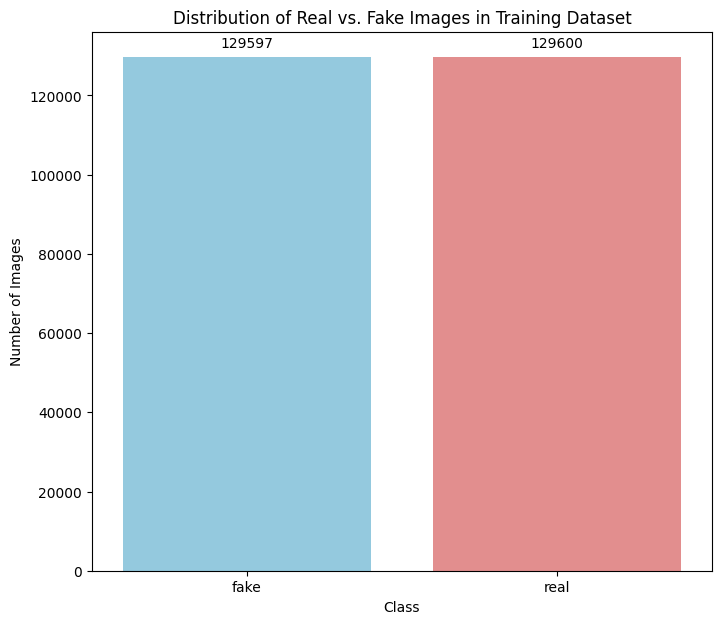

Distribution in Training Dataset:
fake: 129597
real: 129600


In [ ]:
all_labels = []
for sub_dataset in train_dataset.datasets:
    all_labels.extend(sub_dataset.targets)

# Count the occurrences of each class
label_counts = Counter(all_labels)

# Prepare data for plotting
labels = [class_names[i] for i in sorted(label_counts.keys())]
counts = [label_counts[i] for i in sorted(label_counts.keys())]

# Create the bar chart using seaborn
plt.figure(figsize=(8, 7))
ax = sns.barplot(x=labels, y=counts, palette=['skyblue', 'lightcoral'])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Real vs. Fake Images in Training Dataset")

# Add numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

print("Distribution in Training Dataset:")
for label, count in label_counts.items():
    print(f"{class_names[label]}: {count}")

In [ ]:
#denormailising images for viewing
def denormalise(img):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    return img * std[:, None, None] + mean[:, None, None]

In [ ]:
train_dataset.classes = class_names
print(train_dataset.classes)

['fake', 'real']


In [ ]:
print("Classes:", train_dataset.classes)
print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Classes: ['fake', 'real']
Train size: 259197
Val size: 12000
Progan test size: 64800


In [ ]:
print(npr_train_dataset.datasets[0].class_to_idx)

{'fake': 0, 'real': 1}


In [ ]:
#define images, can change with train/test/val for either
train_images, labels = next(iter(npr_train_loader))


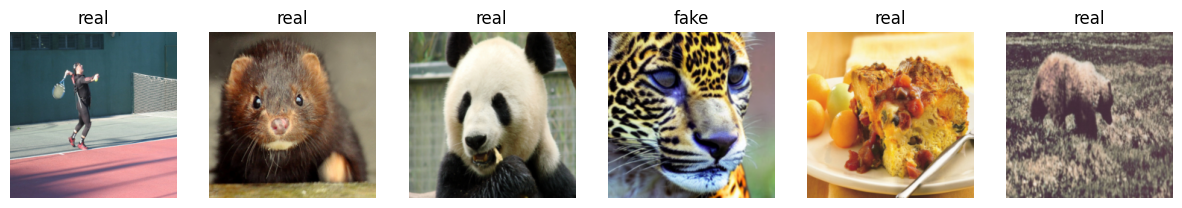

In [ ]:
class_names = npr_train_dataset.datasets[0].classes
fig, axes = plt.subplots(1, 6, figsize=(15, 3))



for i in range(6):
    img = train_images[i].clone()

    img_denorm = denormalise(img)
    img_denorm = img_denorm.clamp(0, 1)

    dmImg = img_denorm.permute(1, 2, 0)
    label = class_names[labels[i].item()]

    axes[i].imshow(dmImg)
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

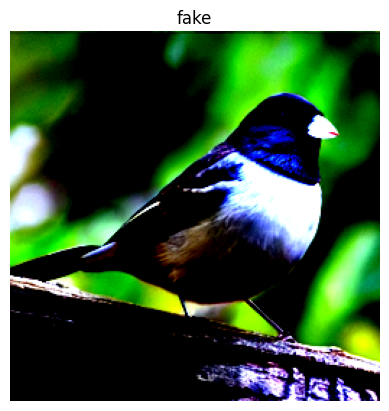

In [ ]:
img, label = npr_train_dataset[1]

img_denorm = denormalise(img)

plt.imshow(img.permute(1, 2, 0))
plt.title(npr_train_dataset.datasets[0].classes[label])
plt.axis("off")

plt.show()

# 4 Baseline

### ResNet50 Baseline Architecture

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

baseline_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

num_features = baseline_model.fc.in_features
baseline_model.fc = nn.Linear(num_features, 2)

adapted from https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html


In [ ]:
def baseline_train_model(model, criterion, optimizer, scheduler, num_epochs, mod_path):
    since = time.time()

    best_model_params_path = mod_path
    torch.save(model.state_dict(), best_model_params_path)
    best_acc = 0.0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    val_aps = [] # Added for AP metric

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
                dataloader = train_loader
                dataset_size = len(train_dataset)
            else:
                model.eval()
                dataloader = val_loader
                dataset_size = len(val_dataset)

            running_loss = 0.0

            # reset metric each phase
            acc_metric = MulticlassAccuracy(num_classes=2).to(device)

            all_probs = [] # To store probabilities for AP calculation
            all_labels = [] # To store true labels for AP calculation

            loop = tqdm(dataloader, desc=phase, leave=True)

            for inputs, labels in loop:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)              # shape [batch, 2]
                    loss = criterion(outputs, labels)    # labels shape [batch]

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                # Get probabilities for class 1 (assuming 'fake' is positive class, index 1)
                probs = torch.softmax(outputs, dim=1)[:, 1]
                all_probs.extend(probs.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

                # update accuracy metric using logits directly
                acc_metric.update(outputs, labels)

                # batch display
                batch_preds = torch.argmax(outputs, dim=1)
                batch_acc = (batch_preds == labels).float().mean().item()
                loop.set_postfix(loss=f"{loss.item():.4f}", batch_acc=f"{batch_acc:.4f}")

            if phase == "train":
                scheduler.step()

            epoch_loss = running_loss / dataset_size
            epoch_acc = acc_metric.compute().item()

            if phase == "val":
                epoch_ap = average_precision_score(all_labels, all_probs)
                val_aps.append(epoch_ap)
                print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} AP: {epoch_ap:.4f}")
            else:
                print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc)

            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), best_model_params_path)

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(torch.load(best_model_params_path, map_location=device))
    return model, train_losses, val_losses, train_accs, val_accs, val_aps

In [ ]:
# Define the loss function and optimizer
bl_criterion = torch.nn.CrossEntropyLoss()
bl_optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001)
bl_scheduler = lr_scheduler.StepLR(bl_optimizer, step_size=7, gamma=0.1)

In [ ]:
rn_model = baseline_model.to(device)
trained_baseline_model = baseline_train_model(
    rn_model,
    bl_criterion,
    bl_optimizer,
    bl_scheduler,
    num_epochs=25,
    mod_path ="/content/drive/MyDrive/Thesis/Models/baseline_model_proper_25.pth")

Epoch 1/25
----------


train: 100%|██████████| 8100/8100 [30:09<00:00,  4.48it/s, batch_acc=1.0000, loss=0.0356]


train Loss: 0.2197 Acc: 0.9101


val: 100%|██████████| 375/375 [01:13<00:00,  5.10it/s, batch_acc=0.7188, loss=0.5960]


val Loss: 0.2614 Acc: 0.8913 AP: 0.9935

Epoch 2/25
----------


...

val Loss: 0.0075 Acc: 0.9973 AP: 1.0000

Epoch 25/25
----------


train: 100%|██████████| 8100/8100 [29:56<00:00,  4.51it/s, batch_acc=0.9655, loss=0.0506]


train Loss: 0.0362 Acc: 0.9861


val: 100%|██████████| 375/375 [01:13<00:00,  5.13it/s, batch_acc=1.0000, loss=0.0004]


val Loss: 0.0076 Acc: 0.9973 AP: 1.0000

Training complete in 784m 37s
Best val Acc: 0.9973


In [ ]:
# from google.colab import runtime
# runtime.unassign()

# 5 NPR Adaptation

from https://github.com/chuangchuangtan/NPR-DeepfakeDetection

In [ ]:

def conv3x3(in_planes, out_planes, stride=1):
    return nn.Conv2d(
        in_planes, out_planes, kernel_size=3, stride=stride, padding=1, bias=False
    )


def conv1x1(in_planes, out_planes, stride=1):
    return nn.Conv2d(
        in_planes, out_planes, kernel_size=1, stride=stride, bias=False
    )


In [ ]:
class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm2d(planes)

        self.conv2 = conv3x3(planes, planes, stride)
        self.bn2 = nn.BatchNorm2d(planes)

        self.conv3 = conv1x1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm2d(planes * self.expansion)

        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out = out + identity
        out = self.relu(out)
        return out


class NPRResNet50(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        self.inplanes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, 3)
        self.layer2 = self._make_layer(128, 4, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(512, num_classes)

    def _make_layer(self, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * Bottleneck.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * Bottleneck.expansion, stride),
                nn.BatchNorm2d(planes * Bottleneck.expansion),
            )

        layers = [Bottleneck(self.inplanes, planes, stride, downsample)]
        self.inplanes = planes * Bottleneck.expansion

        for _ in range(1, blocks):
            layers.append(Bottleneck(self.inplanes, planes))

        return nn.Sequential(*layers)

    def interpolate_residual(self, img, factor=0.5):
        img_small = F.interpolate(
            img, scale_factor=factor, mode="nearest", recompute_scale_factor=True
        )
        img_recon = F.interpolate(
            img_small,
            scale_factor=1 / factor,
            mode="nearest",
            recompute_scale_factor=True
        )
        return img - img_recon

    def forward(self, x):
        npr = self.interpolate_residual(x, 0.5)

        x = self.conv1(npr * 2.0 / 3.0)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        return x


def resnet50(num_classes=1):
    return NPRResNet50(num_classes=num_classes)

In [ ]:
def npr_train_model(model, criterion, optimizer, num_epochs, mod_path):
    since = time.time()

    best_model_params_path = mod_path
    torch.save(model.state_dict(), best_model_params_path)
    best_acc = 0.0

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    val_aps = []

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 10)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
                dataloader = npr_train_loader
                dataset_size = len(npr_train_dataset)
            else:
                model.eval()
                dataloader = npr_val_loader
                dataset_size = len(npr_val_dataset)

            running_loss = 0.0
            acc_metric = BinaryAccuracy().to(device)

            all_probs = []
            all_labels = []

            loop = tqdm(dataloader, desc=phase, leave=True)

            for inputs, labels in loop:
                inputs = inputs.to(device)
                labels = labels.to(device).float()

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs).squeeze(1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)

                probs = torch.sigmoid(outputs)
                acc_metric.update(probs, labels.int())

                all_probs.extend(probs.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

                batch_preds = (probs >= 0.5).long()
                batch_acc = (batch_preds == labels.long()).float().mean().item()
                loop.set_postfix(
                    loss=f"{loss.item():.4f}",
                    batch_acc=f"{batch_acc:.4f}",
                    lr=f"{optimizer.param_groups[0]['lr']:.6f}"
                )

            epoch_loss = running_loss / dataset_size
            epoch_acc = acc_metric.compute().item()

            if phase == "val":
                epoch_ap = average_precision_score(all_labels, all_probs)
                val_aps.append(epoch_ap)
                print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} AP: {epoch_ap:.4f}")
            else:
                print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            if phase == "train":
                train_losses.append(epoch_loss)
                train_accs.append(epoch_acc)
            else:
                val_losses.append(epoch_loss)
                val_accs.append(epoch_acc)

            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                torch.save(model.state_dict(), best_model_params_path)

        # manual learning-rate decay: every 20 epochs, multiply by 0.9
        if epoch % 20 == 0 and epoch != 0:
            for param_group in optimizer.param_groups:
                old_lr = param_group["lr"]
                param_group["lr"] *= 0.9
                print("*" * 25)
                print(f"Changing lr from {old_lr} to {param_group['lr']}")
                print("*" * 25)

        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(torch.load(best_model_params_path, map_location=device))
    return model, train_losses, val_losses, train_accs, val_accs, val_aps

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
npr_model = resnet50(num_classes=1).to(device)

In [ ]:
npr_criterion = torch.nn.BCEWithLogitsLoss()
npr_optimizer = torch.optim.Adam(
    npr_model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999)
)

In [ ]:
print("train:", npr_train_dataset.datasets[0].class_to_idx)
print("val:  ", npr_val_dataset.datasets[0].class_to_idx)
print("test: ", npr_test_dataset.datasets[0].class_to_idx)

train: {'real': 0, 'fake': 1}
val:   {'real': 0, 'fake': 1}
test:  {'real': 0, 'fake': 1}


In [ ]:
# train npr model
npr_model, train_losses, val_losses, train_accs, val_accs, val_aps = npr_train_model(
    npr_model,
    npr_criterion,
    npr_optimizer,
    num_epochs=25,
    mod_path="/content/drive/MyDrive/Thesis/Models/npr_model.pth"
)

Epoch 1/25
----------


train: 100%|██████████| 8100/8100 [29:38<00:00,  4.55it/s, batch_acc=0.9655, loss=0.2338, lr=0.000100]


train Loss: 0.1650 Acc: 0.9329


val: 100%|██████████| 375/375 [01:12<00:00,  5.14it/s, batch_acc=1.0000, loss=0.0378, lr=0.000100]


val Loss: 0.0605 Acc: 0.9789 AP: 0.9977

Epoch 2/25
----------


...

val Loss: 0.0033 Acc: 0.9985 AP: 1.0000

Epoch 25/25
----------


train: 100%|██████████| 8100/8100 [28:42<00:00,  4.70it/s, batch_acc=1.0000, loss=0.0000, lr=0.000090]


train Loss: 0.0078 Acc: 0.9974


val: 100%|██████████| 375/375 [01:11<00:00,  5.24it/s, batch_acc=1.0000, loss=0.0001, lr=0.000090]


val Loss: 0.0054 Acc: 0.9982 AP: 1.0000

Training complete in 754m 7s
Best val Acc: 0.9991


---

## NPR VISUALISATION

In [ ]:

# Get one image from dataset
img, label = test_dataset[13000]
label_name = test_dataset.classes[label]

# Add batch dimension: [C, H, W] -> [1, C, H, W]
img_batch = img.unsqueeze(0).to(device)

npr_model_test.eval()

with torch.no_grad():
    npr_map = npr_model_test.interpolate_residual(img_batch, factor=0.5)

print("Original image shape:", img_batch.shape)
print("NPR map shape:", npr_map.shape)
print("NPR min:", npr_map.min().item())
print("NPR max:", npr_map.max().item())

Original image shape: torch.Size([1, 3, 224, 224])
NPR map shape: torch.Size([1, 3, 224, 224])
NPR min: -2.5560224056243896
NPR max: 2.6785717010498047


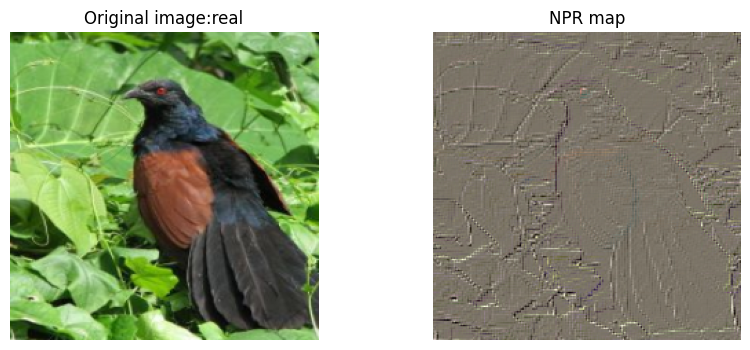

In [ ]:
# Move tensors to CPU
img_cpu = img_batch.squeeze(0).cpu()
npr_cpu = npr_map.squeeze(0).cpu()

dm_cpu = denormalise(img_cpu)
dm_npr = denormalise(npr_cpu)


# Convert from [C, H, W] to [H, W, C]
img_np = dm_cpu.permute(1, 2, 0).numpy()
npr_np = dm_npr.permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title(f"Original image:{label_name}")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(npr_np)
plt.title("NPR map")
plt.axis("off")

plt.show()

# 6 Evaluation

### Load Baseline Model

In [ ]:
import torch
from torchvision import models
import torch.nn as nn

In [ ]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bl_model = models.resnet50(weights=None)
bl_model.fc = nn.Linear(bl_model.fc.in_features, 2)

# Load state_dict directly to the correct device
bl_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/Models/baseline_model_proper_25.pth", map_location=device))
bl_model_test = bl_model.to(device)
bl_model_test.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Load NPR Model

In [ ]:
npr_model_test = resnet50(num_classes=1)
npr_model_test.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/Models/npr_model_augs.pth", map_location='cpu'), strict=True)
npr_model_test.cuda()
npr_model_test.eval()

NPRResNet50(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride

### Load Test Datasets

In [ ]:
progan_dataset_bl = datasets.ImageFolder("/content/ProGan", transform=transform_eval)


In [ ]:
#Midjourney, StyleGan, SD3, ProGan, R3GAN, GLIDE, SocialRF
#Baseline loaders
progan_dataset_bl = datasets.ImageFolder("/content/ProGan", transform=transform_eval)

r3_dataset_bl = datasets.ImageFolder("/content/R3GAN", transform=transform_eval)

mj_dataset_bl = datasets.ImageFolder("/content/Midjourney", transform=transform_eval)

style_dataset_bl = datasets.ImageFolder("/content/StyleGan", transform=transform_eval)

sd3_dataset_bl = datasets.ImageFolder("/content/SD3", transform=transform_eval)

glide_dataset_bl = datasets.ImageFolder("/content/GLIDE", transform=transform_eval)

socialrf_dataset_bl = datasets.ImageFolder("/content/SocialRF", transform=transform_eval)



FileNotFoundError: [Errno 2] No such file or directory: '/content/R3GAN'

### NPR Datasets

In [ ]:
progan_dataset = datasets.ImageFolder("/content/ProGan", transform=npr_transform_test)


In [ ]:
#Midjourney, StyleGan, SD3, ProGan, R3GAN, GLIDE, SocialRF
progan_dataset = datasets.ImageFolder("/content/ProGan", transform=npr_transform_test)

r3_dataset = datasets.ImageFolder("/content/R3GAN", transform=npr_transform_test)

mj_dataset = datasets.ImageFolder("/content/Midjourney", transform=npr_transform_test)

style_dataset = datasets.ImageFolder("/content/StyleGan", transform=npr_transform_test)

sd3_dataset = datasets.ImageFolder("/content/SD3", transform=npr_transform_test)

glide_dataset = datasets.ImageFolder("/content/GLIDE", transform=npr_transform_test)

socialrf_dataset = datasets.ImageFolder("/content/SocialRF", transform=npr_transform_test)


In [ ]:
print(progan_dataset.class_to_idx)
print(r3_dataset.class_to_idx)
print(mj_dataset.class_to_idx)
print(style_dataset.class_to_idx)
print(sd3_dataset.class_to_idx)
print(glide_dataset.class_to_idx)
print(socialrf_dataset.class_to_idx)

{'fake': 0, 'real': 1}
{'fake': 0, 'real': 1}
{'fake': 0, 'real': 1}
{'fake': 0, 'real': 1}
{'fake': 0, 'real': 1}
{'fake': 0, 'real': 1}
{'fake': 0, 'real': 1}


###NPR test loaders

In [ ]:
progan_loader = DataLoader(
    progan_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


In [ ]:
progan_loader = DataLoader(
    progan_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

r3_loader = DataLoader(
    r3_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

mj_loader =DataLoader(
    mj_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


style_loader =DataLoader(
    style_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
sd3_loader =DataLoader(
    sd3_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

glide_loader =DataLoader(
    glide_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

socialrf_loader =DataLoader(
    socialrf_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


NameError: name 'progan_dataset' is not defined

###BaseLine Test loaders

In [ ]:
bl_progan_loader = DataLoader(
    progan_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
bl_progan_loader = DataLoader(
    progan_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

bl_r3_loader = DataLoader(
    r3_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

bl_mj_loader =DataLoader(
    mj_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

bl_style_loader =DataLoader(
    style_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
bl_sd3_loader =DataLoader(
    sd3_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
bl_glide_loader =DataLoader(
    glide_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
bl_socialrf_loader =DataLoader(
    socialrf_dataset_bl,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
print("SD- Test size:", len(test_dataset))
print("PG- Test size:", len(progan_dataset))
print("R3G- Test size:", len(r3_dataset))
print("MJ- Test size:", len(mj_dataset))
print("Style- Test size:", len(style_dataset))
print("SD3- Test size:", len(sd3_dataset))
print("Glide- Test size:", len(glide_dataset))
print("Social- Test size:", len(socialrf_dataset))

SD- Test size: 64800
PG- Test size: 8000
R3G- Test size: 9000
MJ- Test size: 6000
Style- Test size: 9000
SD3- Test size: 9000
Glide- Test size: 9000
Social- Test size: 6000


In [ ]:
import torch

def test_model(model, dataloader, device, threshold=0.5):
    model.eval()
    preds_list = []
    labels_list = []
    probs_list = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            # Case 1: NPR / binary-logit model -> shape [batch, 1] or [batch]
            if outputs.ndim == 1 or (outputs.ndim == 2 and outputs.shape[1] == 1):
                outputs = outputs.squeeze(1) if outputs.ndim == 2 else outputs
                probs = torch.sigmoid(outputs)
                # Normal prediction logic: >= threshold is class 1 (real, since fake=0)
                preds = (probs >= threshold).long()

            # Case 2: baseline 2-class model -> shape [batch, 2]
            elif outputs.ndim == 2 and outputs.shape[1] == 2:
                probs = torch.softmax(outputs, dim=1)[:, 1]   # probability of class 1 (real)
                preds = outputs.argmax(dim=1)

            else:
                raise ValueError(f"Unexpected output shape: {outputs.shape}")

            preds_list.append(preds.cpu())
            labels_list.append(labels.cpu())
            probs_list.append(probs.cpu())

    preds = torch.cat(preds_list).numpy()
    labels = torch.cat(labels_list).numpy()
    probs = torch.cat(probs_list).numpy()

    return preds, labels, probs

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, average_precision_score

def evaluate_model_performance(model, dataloader, device, threshold=None):
    """
    Evaluates a model's performance using various classification metrics.

    Args:
        model (torch.nn.Module): The trained model.
        dataloader (torch.utils.data.DataLoader): The DataLoader for the dataset to evaluate.
        device (torch.device): The device (cpu/cuda) to run the model on.
        threshold (float, optional): The threshold for binary classification. Defaults to 0.5.

    """
    preds, labels, probs = test_model(model, dataloader, device, threshold)

    acc = accuracy_score(labels, preds)
    # prec = precision_score(labels, preds, zero_division=0)
    # rec = recall_score(labels, preds, zero_division=0)
    # f1 = f1_score(labels, preds, zero_division=0)
    ap = average_precision_score(labels, probs)
    cm = confusion_matrix(labels, preds)

    return acc, ap, cm

In [ ]:
# # Example usage of the new evaluation function for the NPR model on the R3GAN dataset
# acc, ap, cm = evaluate_model_performance(
#     npr_model_test,
#     r3_loader,
#     device,
#     threshold=0.5
#     )

# print(f"Accuracy:  {acc:.4f}")
# # print(f"Precision: {prec:.4f}")
# # print(f"Recall:    {rec:.4f}")
# # print(f"F1-score:  {f1:.4f}")
# print(f"AP:        {ap:.4f}")
# print("Confusion Matrix:\n", cm)

NameError: name 'npr_model_test' is not defined

##Evaluate multiple datasets

In [ ]:
import pandas as pd

def evaluate_multiple_datasets(model, dataloaders_dict, device, threshold=0.5):
    """
    Evaluates a model across multiple datasets and returns a summary DataFrame.
    """
    results = []

    for name, loader in dataloaders_dict.items():
        print(f"Evaluating {name}...")
        acc, ap, cm = evaluate_model_performance(model, loader, device, threshold)

        results.append({
            "Dataset": name,
            "Accuracy": acc,
            # "Precision": prec,
            # "Recall": rec,
            #"F1-score": f1,
            "AP": ap
        })
        print(f"  Done! Accuracy: {acc:.4f}  | AP: {ap:.4f}\n")

    # Convert results list to a Pandas DataFrame for a nice tabular view
    summary_df = pd.DataFrame(results)
    return summary_df



In [ ]:
# Define a dictionary mapping dataset names to their loaders
test_loaders = {
    "SD1.4 (Native)": test_loader,
    "ProGAN": bl_progan_loader,
    "R3GAN": bl_r3_loader,
    "Midjourney": bl_mj_loader,
    "StyleGAN": bl_style_loader,
    "SD3": bl_sd3_loader,
    "Glide": bl_glide_loader,
    "SocialRF": bl_socialrf_loader
}



npr_test_loaders = {
    "SD1.4 (Native)": test_loader,
    "ProGAN": progan_loader,
    "R3GAN": r3_loader,
    "Midjourney": mj_loader,
    "StyleGAN": style_loader,
    "SD3": sd3_loader,
    "Glide": glide_loader,
    "SocialRF": socialrf_loader
    # You can also include your native test loader if you'd like:
}

###baseline evaluate1

In [ ]:
# Run the evaluation loop
summary_results = evaluate_multiple_datasets(bl_model_test, test_loaders, device)

# Display the final summary table
display(summary_results)

Evaluating SD1.4 (Native)...
  Done! Accuracy: 0.9974  | AP: 0.9999

Evaluating ProGAN...
  Done! Accuracy: 0.4995  | AP: 0.4820

Evaluating R3GAN...
  Done! Accuracy: 0.4968  | AP: 0.5477

Evaluating Midjourney...
  Done! Accuracy: 0.5048  | AP: 0.5177

Evaluating StyleGAN...
  Done! Accuracy: 0.5037  | AP: 0.5317

Evaluating SD3...
  Done! Accuracy: 0.5368  | AP: 0.7078

Evaluating Glide...
  Done! Accuracy: 0.5040  | AP: 0.4624

Evaluating SocialRF...
  Done! Accuracy: 0.5573  | AP: 0.5283



,Dataset,Accuracy,AP
0,SD1.4 (Native),0.997377,0.999939
1,ProGAN,0.499500,0.481990
2,R3GAN,0.496778,0.547671
3,Midjourney,0.504833,0.517736
4,StyleGAN,0.503667,0.531674
5,SD3,0.536778,0.707836
6,Glide,0.504000,0.462396
7,SocialRF,0.557333,0.528314


###NPR evaluate

In [ ]:
# Run the evaluation loop
summary_results_npr = evaluate_multiple_datasets(npr_model_test, npr_test_loaders, device)

# Display the final summary table
display(summary_results_npr)

Evaluating SD1.4 (Native)...
  Done! Accuracy: 0.9986  | AP: 1.0000

Evaluating ProGAN...
  Done! Accuracy: 0.8060  | AP: 0.9715

Evaluating R3GAN...
  Done! Accuracy: 0.5158  | AP: 0.7181

Evaluating Midjourney...
  Done! Accuracy: 0.5573  | AP: 0.7646

Evaluating StyleGAN...
  Done! Accuracy: 0.6304  | AP: 0.8697

Evaluating SD3...
  Done! Accuracy: 0.7910  | AP: 0.9571

Evaluating Glide...
  Done! Accuracy: 0.7771  | AP: 0.9250

Evaluating SocialRF...
  Done! Accuracy: 0.5630  | AP: 0.5884



,Dataset,Accuracy,AP
0,SD1.4 (Native),0.998596,0.999984
1,ProGAN,0.806000,0.971521
2,R3GAN,0.515778,0.718120
3,Midjourney,0.557333,0.764596
4,StyleGAN,0.630444,0.869739
5,SD3,0.791000,0.957083
6,Glide,0.777111,0.925012
7,SocialRF,0.563000,0.588398


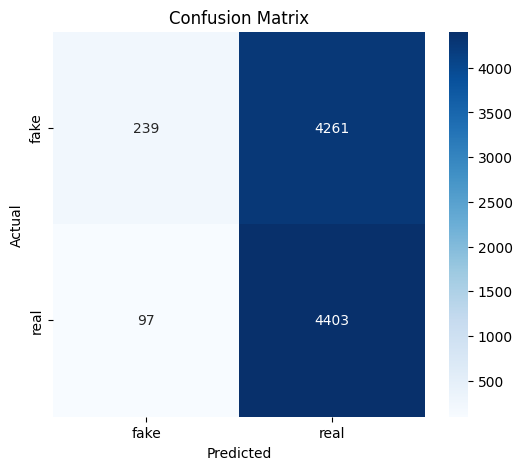

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

class_names = npr_test_dataset.classes

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

##  Image Predictions

In [ ]:
def display_image_prediction(model, dataset, index, class_names, device, is_normalized=False):
    """
    Displays an image from a dataset, along with its true and predicted labels.

    Args:
        model (torch.nn.Module): The trained model to make predictions.
        dataset (torch.utils.data.Dataset): The dataset from which to load the image.
        index (int): The index of the image in the dataset.
        class_names (list): A list of class names (e.g., ['fake', 'real']).
        device (torch.device): The device (cpu/cuda) to run the model on.
        is_normalized (bool): If True, the image will be denormalized before displaying.
    """
    img, label = dataset[index]
    model.eval()

    with torch.no_grad():
        output = model(img.unsqueeze(0).to(device))
        # Assuming a binary classification model where output is a single logit
        # and prediction is based on sigmoid > 0.5
        if output.ndim == 2 and output.shape[1] == 1:
            prob = torch.sigmoid(output.squeeze(1))
            # Normal prediction logic
            pred = (prob >= 0.5).long().item()
        elif output.ndim == 2 and output.shape[1] == 2:
            pred = output.argmax(dim=1).item()
        else:
            raise ValueError("Unsupported model output format for prediction.")

    plt.figure(figsize=(5, 5))
    if is_normalized:
        img_display = denormalise(img)
    else:
        img_display = img

    img_display = img_display.clamp(0, 1)
    plt.imshow(img_display.permute(1, 2, 0))
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

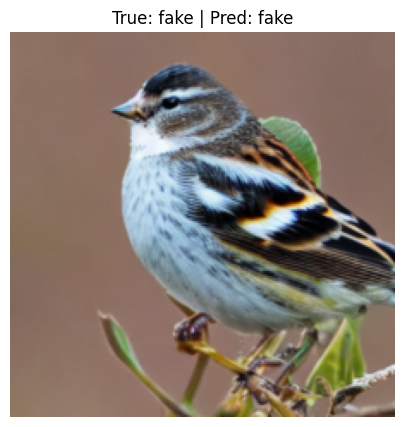

In [ ]:
# Example usage of the new display_image_prediction function
# Using the npr_model_test and progan_dataset with index 555

import matplotlib.pyplot as plt

display_image_prediction(
    model=npr_model_test,
    dataset=test_dataset,
    index=300,
    class_names=class_names,
    device=device,
    is_normalized=True # Set to True if the dataset's transform included normalization
)

In [ ]:

def display_grad_cam(model, img_tensor, true_label, class_names, target_layers, device, is_normalized=True):
    """
    Generates and displays a Grad-CAM visualization for a given image, compatible with both
    binary classification (single logit output) and multi-class classification (multi-logit output).

    Args:
        model (torch.nn.Module): The trained model (either NPRResNet50 or standard ResNet).
        img_tensor (torch.Tensor): The input image tensor (C, H, W).
        true_label (int): The true class label of the image.
        class_names (list): A list of class names.
        target_layers (list): A list of target layers for Grad-CAM.
        device (torch.device): The device (cpu/cuda) to run the model on.
        is_normalized (bool): If True, the image tensor will be denormalised before display.
    """

    input_tensor = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

        # Determine model output type and get prediction
        if isinstance(model, NPRResNet50) or (hasattr(model, 'fc1') and model.fc1.out_features == 1):
            # NPR model or similar binary logit output
            logit_output = output.squeeze(1)
            prob = torch.sigmoid(logit_output)
            # Normal prediction logic
            pred = (prob >= 0.5).long().item()
            # GradCAM target for binary classification with BCEWithLogitsLoss
            targets = [BinaryClassifierOutputTarget(pred)]
        elif hasattr(model, 'fc') and model.fc.out_features == 2:
            # Baseline ResNet or similar 2-class logit output
            probs = torch.softmax(output, dim=1)
            pred = output.argmax(dim=1).item()
            # GradCAM target for multi-class classification with CrossEntropyLoss
            targets = [ClassifierOutputTarget(pred)]
        else:
            raise ValueError(f"Unsupported model output architecture: {model.__class__.__name__}. "
                             f"Expected NPRResNet50 or a model with a 'fc' layer with 2 output features.")

    cam = GradCAM(model=model, target_layers=target_layers)

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]   # first image in batch

    # Denormalise image for display if specified
    if is_normalized:
        rgb_tensor = denormalise(img_tensor)
    else:
        rgb_tensor = img_tensor.cpu()

    rgb_tensor = rgb_tensor.clamp(0, 1)

    # Convert to numpy HWC for show_cam_on_image
    rgb_img = rgb_tensor.permute(1, 2, 0).cpu().numpy()

    # Overlay CAM
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Plot
    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred]}")
    plt.axis("off")
    plt.show()

Grad-CAM for Baseline ResNet:


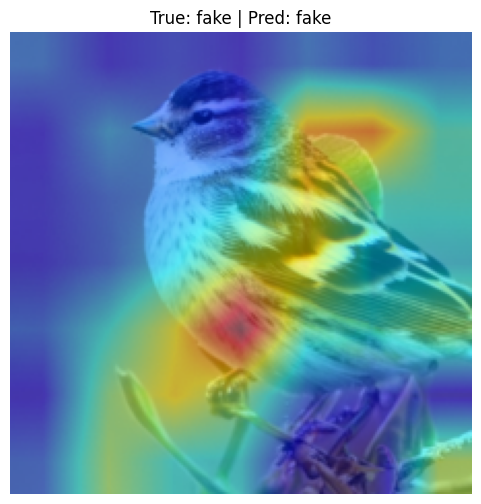

In [ ]:
# Example usage with the baseline ResNet model

# Select an image from the test_dataset (assuming it uses transform_eval compatible with baseline model)
# For baseline model, we use the `model` variable that was loaded from `best_model_params1.pth`
img_tensor_baseline, label_baseline = test_dataset[300]

# Define the target layers for the baseline ResNet model
target_layers_baseline = [bl_model_test.layer4[-1]]

print("Grad-CAM for Baseline ResNet:")
display_grad_cam(
    model=bl_model_test,
    img_tensor=img_tensor_baseline,
    true_label=label_baseline,
    class_names=class_names,
    target_layers=target_layers_baseline,
    device=device,
    is_normalized=True # Baseline model uses normalized transforms
)

Grad-CAM for NPR ResNet:


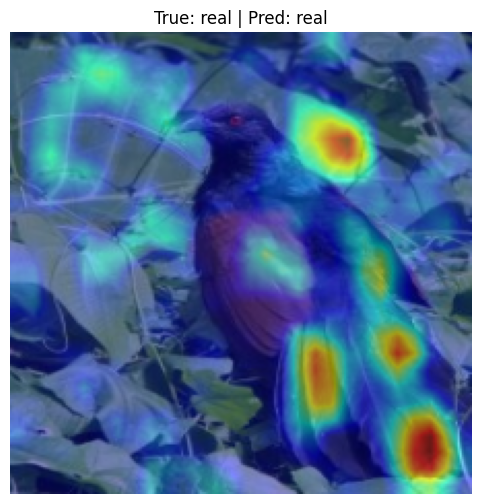

In [ ]:
# Example usage with the NPR ResNet model

# Select an image from the style_dataset (or npr_test_dataset) for the NPR model
img_tensor_npr, label_npr = test_dataset[13000]

# Define the target layers for the NPR ResNet model
target_layers_npr = [npr_model_test.layer2[-1]]

print("Grad-CAM for NPR ResNet:")
display_grad_cam(
    model=npr_model_test,
    img_tensor=img_tensor_npr,
    true_label=label_npr,
    class_names=class_names,
    target_layers=target_layers_npr,
    device=device,
    is_normalized=True # NPR model uses normalized transforms
)

## Utility to Keep Colab Alive

In [ ]:
import time

def keep_colab_alive(minutes):
    """
    Keeps the Colab session alive for a specified number of minutes.
    Useful for preventing disconnection during long processes.
    """
    print(f"Keeping Colab session alive for {minutes} minutes...")
    start_time = time.time()
    end_time = start_time + (minutes * 60)

    while time.time() < end_time:
        current_duration = (time.time() - start_time) / 60
        print(f"\rSession active. Time elapsed: {current_duration:.2f}/{minutes} minutes", end='')
        time.sleep(300) # Sleep for 5 minutes
    print("\nColab session activity loop finished.")


In [ ]:
keep_colab_alive(minutes=2000)

Keeping Colab session alive for 2000 minutes...
Session active. Time elapsed: 30.00/2000 minutes